Saving mldl-4.zip to mldl-4 (1).zip
===== Dataset Preview =====
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

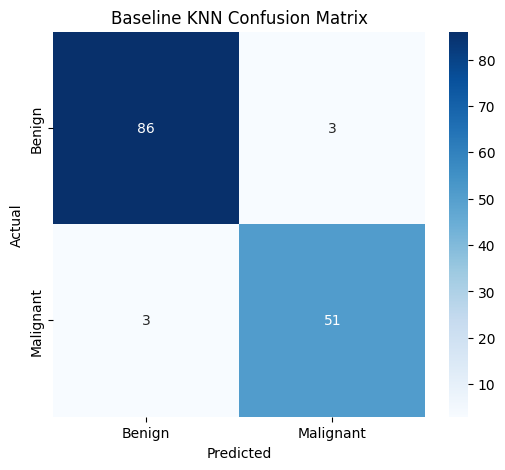

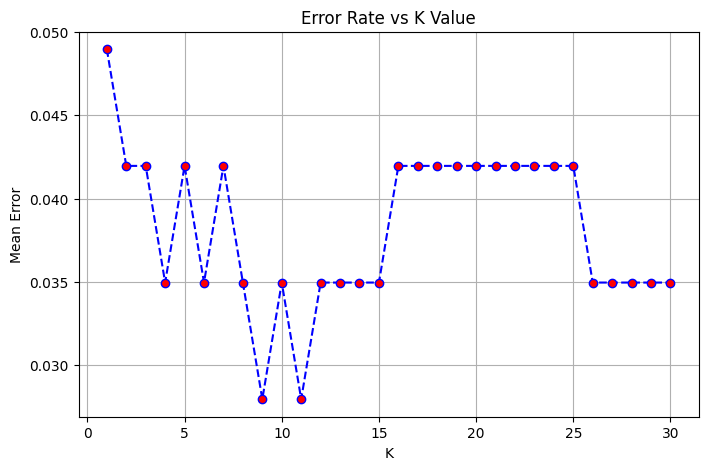


--- TUNED MATHEMATICAL RESULTS ---
Best Parameters: {'metric': 'manhattan', 'n_neighbors': np.int64(3), 'weights': 'uniform'}
Accuracy : 97.20%
Precision: 96.30%
Recall   : 96.30%
F1 Score : 96.30%


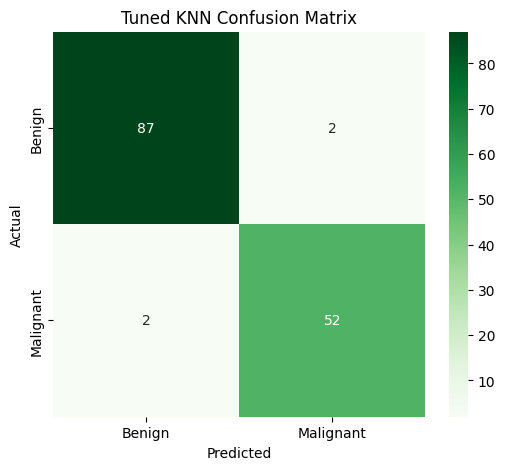

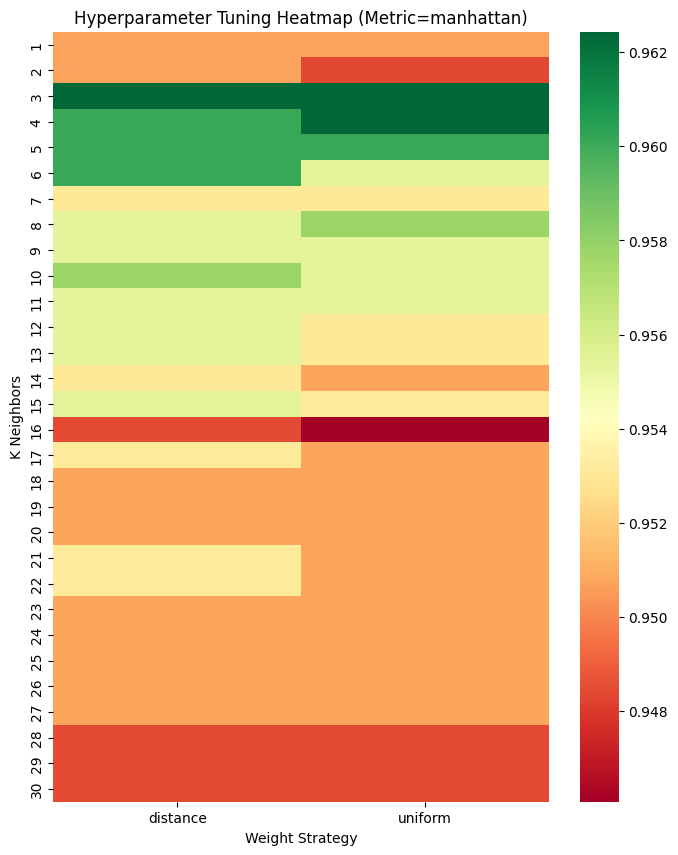

In [ ]:
# =========================================================
# KNN Classification - Breast Cancer Dataset
# (Different from Social Network Ads PDF)
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# ===============================
# Upload Dataset (Colab Safe)
# ===============================

from google.colab import files
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print("===== Dataset Preview =====")
print(df.head())

# ===============================
# Data Cleaning (Fix NaN Error)
# ===============================

# Drop unnecessary columns
df = df.drop(['id', 'Unnamed: 32'], axis=1)

# Convert target to binary
df['diagnosis'] = df['diagnosis'].map({'M':1, 'B':0})

print("\nMissing Values Check:")
print(df.isnull().sum())

# ===============================
# Feature & Target Split
# ===============================

X = df.drop('diagnosis', axis=1).values
y = df['diagnosis'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# ===============================
# Feature Scaling (MANDATORY for KNN)
# ===============================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================================================
# BASELINE KNN (k=5)
# =========================================================

baseline_knn = KNeighborsClassifier(n_neighbors=5)
baseline_knn.fit(X_train_scaled, y_train)

y_pred_baseline = baseline_knn.predict(X_test_scaled)

baseline_acc = accuracy_score(y_test, y_pred_baseline) * 100
baseline_prec = precision_score(y_test, y_pred_baseline) * 100
baseline_rec = recall_score(y_test, y_pred_baseline) * 100
baseline_f1 = f1_score(y_test, y_pred_baseline) * 100

print("\n--- BASELINE MATHEMATICAL RESULTS (k=5) ---")
print(f"Accuracy : {baseline_acc:.2f}%")
print(f"Precision: {baseline_prec:.2f}%")
print(f"Recall   : {baseline_rec:.2f}%")
print(f"F1 Score : {baseline_f1:.2f}%")

# ===============================
# Confusion Matrix (Baseline)
# ===============================

plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test, y_pred_baseline)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign','Malignant'],
            yticklabels=['Benign','Malignant'])
plt.title("Baseline KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =========================================================
# Error Rate vs K (1 to 30)
# =========================================================

error_rate = []

for i in range(1,31):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_scaled, y_train)
    pred_i = knn.predict(X_test_scaled)
    error_rate.append(np.mean(pred_i != y_test))

plt.figure(figsize=(8,5))
plt.plot(range(1,31), error_rate,
         color='blue', linestyle='dashed',
         marker='o', markerfacecolor='red')
plt.title("Error Rate vs K Value")
plt.xlabel("K")
plt.ylabel("Mean Error")
plt.grid(True)
plt.show()

# =========================================================
# HYPERPARAMETER TUNING
# =========================================================

param_grid = {
    'n_neighbors': np.arange(1,31),
    'weights': ['uniform','distance'],
    'metric': ['euclidean','manhattan']
}

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

best_knn = grid_search.best_estimator_
y_pred_tuned = best_knn.predict(X_test_scaled)

tuned_acc = accuracy_score(y_test, y_pred_tuned) * 100
tuned_prec = precision_score(y_test, y_pred_tuned) * 100
tuned_rec = recall_score(y_test, y_pred_tuned) * 100
tuned_f1 = f1_score(y_test, y_pred_tuned) * 100

print("\n--- TUNED MATHEMATICAL RESULTS ---")
print("Best Parameters:", grid_search.best_params_)
print(f"Accuracy : {tuned_acc:.2f}%")
print(f"Precision: {tuned_prec:.2f}%")
print(f"Recall   : {tuned_rec:.2f}%")
print(f"F1 Score : {tuned_f1:.2f}%")

# ===============================
# Confusion Matrix (Tuned)
# ===============================

plt.figure(figsize=(6,5))
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Benign','Malignant'],
            yticklabels=['Benign','Malignant'])
plt.title("Tuned KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =========================================================
# Hyperparameter Heatmap
# =========================================================

results_df = pd.DataFrame(grid_search.cv_results_)

best_metric = grid_search.best_params_['metric']
subset = results_df[results_df['param_metric'] == best_metric]

pivot_table = subset.pivot(
    index='param_n_neighbors',
    columns='param_weights',
    values='mean_test_score'
)

plt.figure(figsize=(8,10))
sns.heatmap(pivot_table, cmap='RdYlGn')
plt.title(f"Hyperparameter Tuning Heatmap (Metric={best_metric})")
plt.ylabel("K Neighbors")
plt.xlabel("Weight Strategy")
plt.show()